# Predictive Maintenance - Machine Learning Capstone

**Objective:** The primary goal of this capstone project is to develop a robust machine learning classification model. This model will use telemetry and sensor data from machinery—such as air temperature, process temperature, rotational speed, torque, and tool wear—to predict the likelihood of equipment failure before it happens. 

By proactively identifying these risks, organizations can shift from *reactive* maintenance (fixing things after they break) to *predictive* maintenance (scheduling dynamic repairs optimally), drastically reducing unplanned downtime and operational costs.

### Environment Setup & Library Imports
In this initial cell, we import all necessary libraries to construct our pipeline:
* **Pandas & NumPy**: For extensive data manipulation, cleaning, and mathematical operations.
* **Matplotlib & Seaborn**: For generating high-quality exploratory data analysis (EDA) visualizations.
* **Scikit-Learn**: For our machine learning infrastructure, model evaluation metrics, and preprocessing tools.
* **XGBoost**: For implementing an advanced, tree-based gradient boosting algorithm known for extremely high performance.
* **Joblib**: To safely serialize and export our trained models so they can be securely loaded by our Streamlit web application.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib

import warnings
warnings.filterwarnings('ignore')

## 1. Exploratory Data Analysis (EDA)
In this phase, we initiate our data ingestion pipeline and examine the fundamental shape, integrity, and descriptive statistics of our telemetry dataset.

**Key Steps Taken:**
1. **Load Data**: Reading the `predictive_maintenance.csv` file into a Pandas DataFrame.
2. **Structural Overview**: Assessing the dimensions of the data (rows and columns) and verifying statistical data types.
3. **Missing Value Analysis**: Confirming there are no implicit missing sensor readings that could break our mathematical logic later.

In [2]:
# Load the dataset
df = pd.read_csv('predictive_maintenance.csv')
display(df.head())
display(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,1,M14860,M,298.1,308.6,1551,42.8,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 703.3+ KB


None


Missing Values:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
dtype: int64


### 1.1 Target Class Imbalance & Feature Correlation
Machine failure data naturally suffers from extreme **class imbalance**—healthy operations massively outnumber failure events. We will visually confirm this disparity using a count plot.

Additionally, we generate a **Correlation Heatmap** to map out linear relationships between numeric features. For instance, we expect strong physics-based correlations (like the negative correlation between Torque and Rotational Speed) which may heavily influence our models.

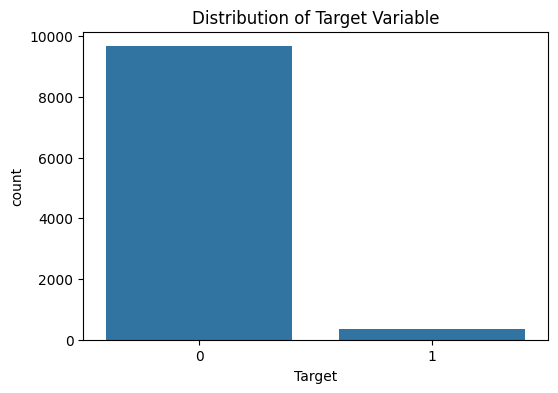

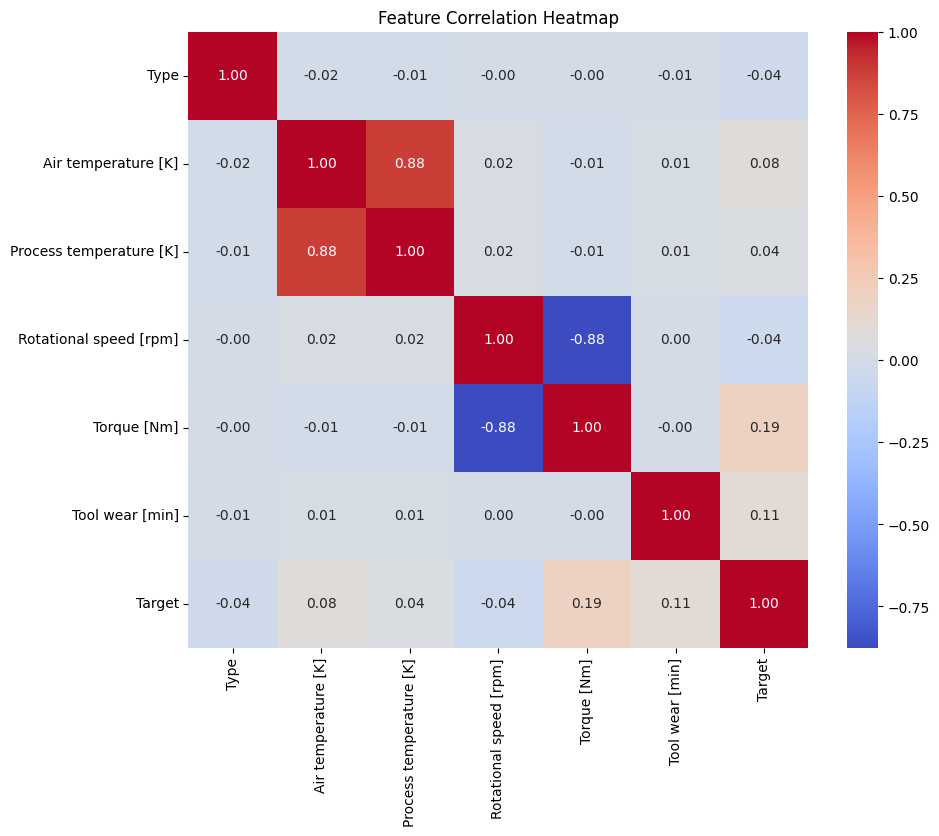

In [3]:
# Check Class Imbalance
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Target')
plt.title('Distribution of Target Variable')
plt.show()

# Drop non-predictive columns early for correlation heatmap
df_copy = df.drop(columns=['UDI', 'Product ID'])

# Encoding categorical variable 'Type' to numeric for correlation mapping
df_copy['Type'] = df_copy['Type'].map({'L': 0, 'M': 1, 'H': 2})

# Correlation Heatmap
plt.figure(figsize=(10,8))
corr = df_copy.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

### 1.2 Feature Distributions Across Machine Status
To understand exactly what physical conditions trigger a failure, we plot the continuous distribution of each feature distinguished by the `Target` class (Healthy Status vs. Failure Status).
This helps us visually detect if high peaks in `Torque` or long durations of `Tool Wear` perfectly align with crash events.

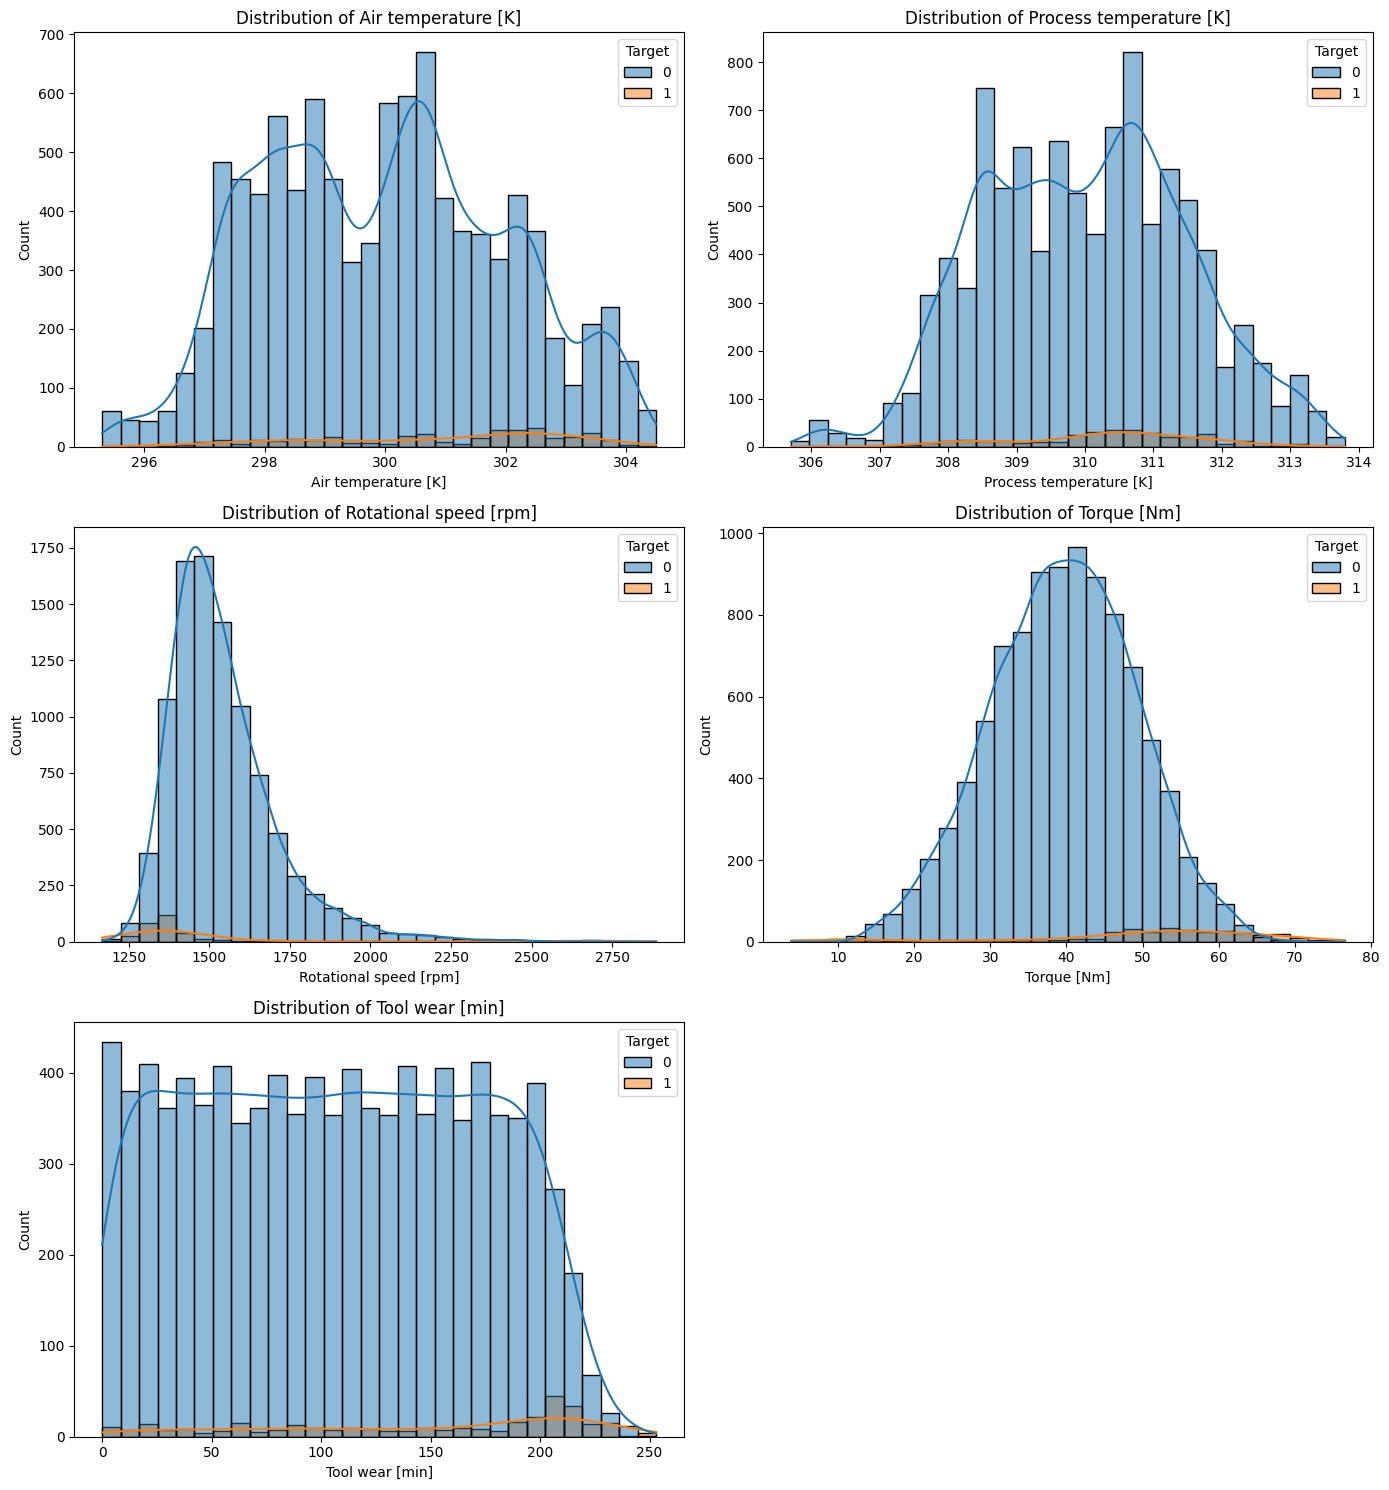

In [4]:
# Visualizing relationships between features and Target
features_to_plot = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 15))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    sns.histplot(data=df, x=feature, hue='Target', kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'Distribution of {feature}')

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

## 1.5. Data Robustness Checks (Duplicates, Skewness, Outliers)

1. **Duplicates Check**: Ensures duplicated sensor glitches do not bias our model training.
2. **Skewness Check**: Symmetrical data yields the best mathematical gradients. We calculate skewness to identify if variables have extreme "long tails" requiring a Logarithmic Transformation.
3. **Outlier Detection via IQR**: We visualize and calculate statistical outliers. Crucially, in Predictive Maintenance datasets, extreme outliers often represent actual catastrophic machine crash signatures. Therefore, instead of deleting these valuable signals, we will adopt a `RobustScaler` in the next cell to cleanly encapsulate them.

Duplicates found: 0

Skewness:
Air temperature [K]        0.114274
Process temperature [K]    0.015027
Rotational speed [rpm]     1.993171
Torque [Nm]               -0.009517
Tool wear [min]            0.027292
dtype: float64
Notice that 'Rotational speed [rpm]' is highly right-skewed. We will apply a Log transformation to it during preprocessing.


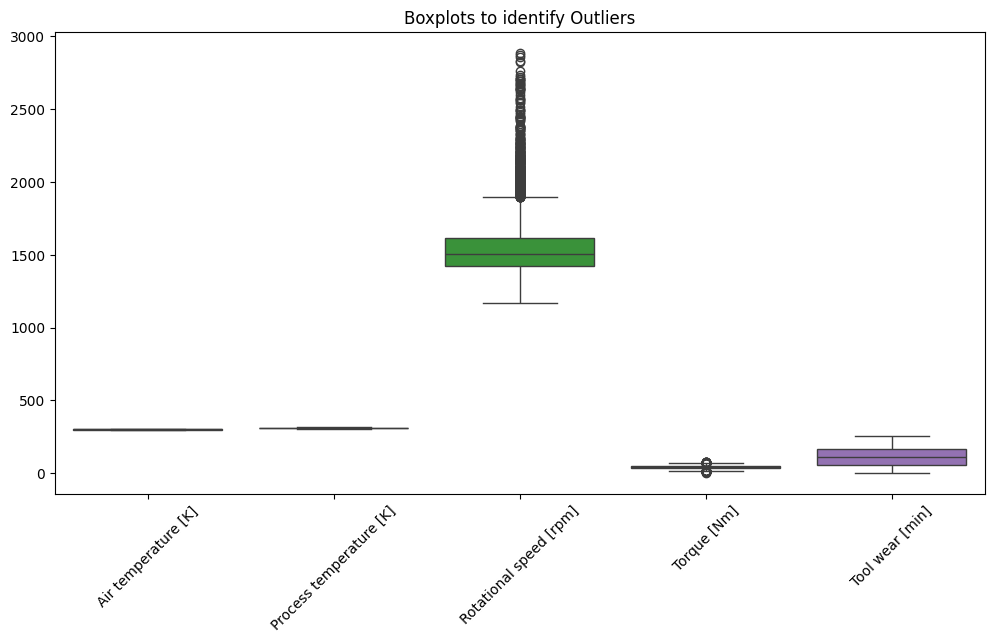


Outliers detected (IQR method):
Air temperature [K]          0
Process temperature [K]      0
Rotational speed [rpm]     418
Torque [Nm]                 69
Tool wear [min]              0
dtype: int64

Mathematical Conclusion: Because extreme anomalies in predictive maintenance typically indicate genuine machine crashes, we will NOT delete these outliers. Instead, we will scale using `RobustScaler` which isolates them safely.


In [5]:
# 1. Duplicates
duplicates = df.duplicated().sum()
print(f"Duplicates found: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")

# 2. Skewness
# We check continuous variables
cont_vars = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
print("\nSkewness:")
print(df[cont_vars].skew())
print("Notice that 'Rotational speed [rpm]' is highly right-skewed. We will apply a Log transformation to it during preprocessing.")

# 3. Outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[cont_vars])
plt.xticks(rotation=45)
plt.title("Boxplots to identify Outliers")
plt.show()

# Calculate outliers using IQR
Q1 = df[cont_vars].quantile(0.25)
Q3 = df[cont_vars].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[cont_vars] < (Q1 - 1.5 * IQR)) | (df[cont_vars] > (Q3 + 1.5 * IQR))).sum()
print("\nOutliers detected (IQR method):")
print(outliers)
print("\nMathematical Conclusion: Because extreme anomalies in predictive maintenance typically indicate genuine machine crashes, we will NOT delete these outliers. Instead, we will scale using `RobustScaler` which isolates them safely.")

## 2. Data Preprocessing & Feature Engineering
With our EDA and robustness decisions finalized, we now transform the raw dataset to format it perfectly for our AI models.

**Preprocessing Pipeline Sequence:**
* **Dimensionality Reduction**: We drop arbitrary text IDs (`UDI` and `Product ID`) because database indices hold no real-world physics characteristics.
* **Skewness Correction (Log Transform)**: Having detected a positive skew above in `Rotational speed [rpm]`, we apply a `np.log1p` transformation to round out its distribution symmetrically.
* **Categorical Encoding**: We apply One-Hot Encoding (`pd.get_dummies`) to the categorical `Type` feature to convert text into mathematical 0s and 1s.
* **Data Splitting**: Sliced into 80% Training and 20% Testing sets using `stratify=y` to ensure the extremely rare '1' failure events are spread properly across both groups.
* **Robust Feature Scaling**: Instead of standard standard-deviation math, we use **`RobustScaler`**. This centers all measurements using Median and IQR mathematics, aligning the bulk of the numbers but preserving extreme outlier Crash signals unaltered!

In [6]:
# Data Preparation
df_prep = df.drop(columns=['UDI', 'Product ID'])

# Handle Skewness using Log Transform
df_prep['Rotational speed [rpm]'] = np.log1p(df_prep['Rotational speed [rpm]'])

# Encoding categorical 'Type' feature 
df_prep = pd.get_dummies(df_prep, columns=['Type'], drop_first=True)

# Separate Features (X) and Target (y)
X = df_prep.drop(columns=['Target'])
y = df_prep['Target']

# Splitting Data into Train and Test Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling using RobustScaler to handle outliers intelligently
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler for future inference via the Streamlit App
joblib.dump(scaler, 'scaler.pkl')

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (8000, 7)
X_test shape: (2000, 7)


## 3. ML  Model Building & Benchmarking
Predicting machine failure correctly is extremely challenging due to the heavy 96/4 Class Imbalance. If an algorithm simply guessed "Healthy" every single time, it would falsely boast 96% Accuracy but would be completely useless to an engineer on the factory floor. 

To overcome this, we train an ensemble of five distinct powerful classification algorithms and command them to severely penalize misses on the minority class (`class_weight='balanced'`). 

**Evaluation Philosophy:**
While `Accuracy` is measured, our primary focus is the **F1-Score** and **Recall**. Missing an actual catastrophic machine failure (a False Negative) bears devastating downtime consequences compared to preemptively stopping a machine to run a check. We heavily optimize for capturing positive breakdown instances.

In [7]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=10),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100),
    "SVM": SVC(class_weight='balanced', random_state=42, probability=True),
    "XGBoost": XGBClassifier(scale_pos_weight=(len(y_train) - sum(y_train))/sum(y_train), random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# Dictionary to store results
results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })
    
    # Store confusion matrices
    print(f"\nClassification Report for {name}:")
    print(classification_report(y_test, y_pred))
    print("-" * 60)

Training Logistic Regression...

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.99      0.81      0.89      1932
           1       0.13      0.81      0.23        68

    accuracy                           0.81      2000
   macro avg       0.56      0.81      0.56      2000
weighted avg       0.96      0.81      0.87      2000

------------------------------------------------------------
Training Decision Tree...

Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1932
           1       0.44      0.71      0.54        68

    accuracy                           0.96      2000
   macro avg       0.71      0.84      0.76      2000
weighted avg       0.97      0.96      0.96      2000

------------------------------------------------------------
Training Random Forest...

Classification Report for Random Forest:
        

### 3.1 Model Comparison & Selection
We compile all of our cross-validation metrics into a comparative DataFrame and visualize the rankings. 

Typically, tree-based ensemble models (like Random Forest and extreme Gradient Boosting XGBoost) dominate physical sensor data classification because they do not rely on standard linear boundaries, seamlessly carving out hyper-complex multi-dimensional thresholds.

,Model,Accuracy,Precision,Recall,F1-Score
4,XGBoost,0.9810,0.702703,0.764706,0.732394
2,Random Forest,0.9810,0.941176,0.470588,0.627451
1,Decision Tree,0.9595,0.440367,0.705882,0.542373
3,SVM,0.9170,0.279279,0.911765,0.427586
0,Logistic Regression,0.8125,0.131894,0.808824,0.226804


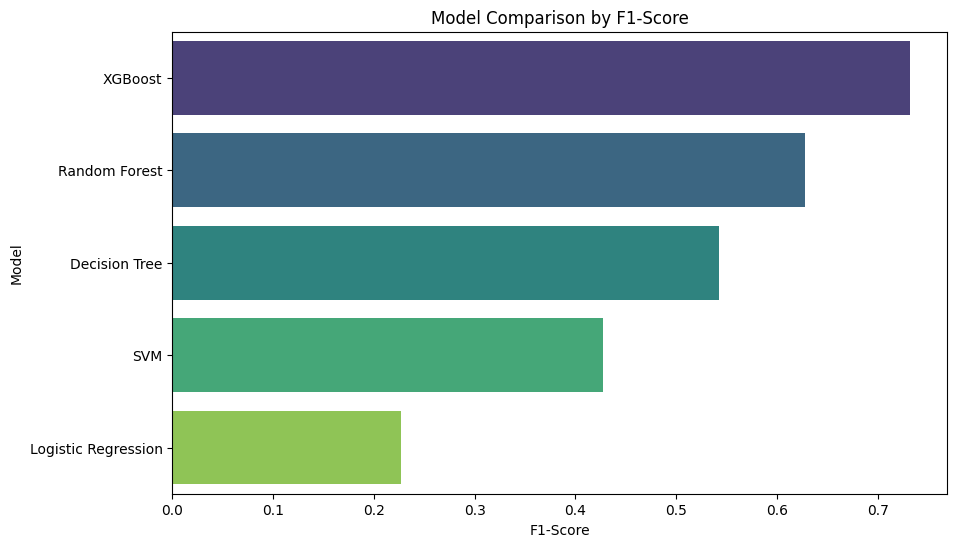

In [8]:
# Comparing Model Performances
results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
display(results_df)

# Plotting F1-Scores
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x="F1-Score", y="Model", palette="viridis")
plt.title("Model Comparison by F1-Score")
plt.show()

## 3.2 XGBoost Hyperparameter Tuning
From the benchmark comparisons above, **XGBoost** emerges as the top-performing model given its powerful gradient boosting mechanism for imbalanced datasets.

We now perform **Randomized Search Cross-Validation (`RandomizedSearchCV`)** on XGBoost to systematically search its key hyperparameter space and discover the optimal configuration.

**Parameters being tuned:**
- `n_estimators`: Number of boosting rounds (more = richer learning, slower training)
- `max_depth`: Maximum tree depth (controls complexity vs. overfitting)
- `learning_rate`: Step size shrinkage to prevent overfitting
- `subsample`: Fraction of samples per tree (adds randomness, reduces overfitting)
- `colsample_bytree`: Fraction of features per tree
- `gamma`: Minimum loss reduction to make a further partition
- `reg_alpha` / `reg_lambda`: L1 and L2 regularisation strengths

`RandomizedSearchCV` is preferred over `GridSearchCV` here because it evaluates a random **subset** of hyperparameter combinations, making it significantly faster while still discovering near-optimal settings efficiently.

In [11]:
from sklearn.model_selection import RandomizedSearchCV

# Hyperparameter grid for XGBoost
param_dist = {
    'n_estimators':      [100, 200, 300, 400, 500],
    'max_depth':         [3, 4, 5, 6, 7, 8],
    'learning_rate':     [0.01, 0.05, 0.1, 0.15, 0.2],
    'subsample':         [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':  [0.5, 0.6, 0.7, 0.8, 1.0],
    'gamma':             [0, 0.1, 0.2, 0.3, 0.5],
    'reg_alpha':         [0, 0.01, 0.1, 0.5, 1.0],
    'reg_lambda':        [0.5, 1.0, 1.5, 2.0, 5.0],
}

base_xgb = XGBClassifier(
    scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

rand_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_dist,
    n_iter=50,
    scoring='f1',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rand_search.fit(X_train_scaled, y_train)

print("Best Parameters Found:")
print(rand_search.best_params_)

# Evaluate the tuned model
best_xgb = rand_search.best_estimator_
y_pred_tuned = best_xgb.predict(X_test_scaled)

print("\n--- Tuned XGBoost Performance ---")
print(classification_report(y_test, y_pred_tuned))
print(f"Tuned Accuracy  : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Tuned F1-Score : {f1_score(y_test, y_pred_tuned):.4f}")
print(f"Tuned Recall   : {recall_score(y_test, y_pred_tuned):.4f}")
print(f"Tuned Precision: {precision_score(y_test, y_pred_tuned):.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters Found:
{'subsample': 0.6, 'reg_lambda': 1.5, 'reg_alpha': 0.01, 'n_estimators': 400, 'max_depth': 7, 'learning_rate': 0.2, 'gamma': 0.2, 'colsample_bytree': 1.0}

--- Tuned XGBoost Performance ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.76      0.79      0.78        68

    accuracy                           0.98      2000
   macro avg       0.88      0.89      0.88      2000
weighted avg       0.98      0.98      0.98      2000

Tuned Accuracy  : 0.9845
Tuned F1-Score : 0.7770
Tuned Recall   : 0.7941
Tuned Precision: 0.7606


## 4. Model Serialization & Export for Production
Having successfully tuned the XGBoost hyperparameters and confirmed peak performance, the final step is to transition from research into a "production-ready" phase.

We utilize the `joblib` library to serialize three critical artifacts:
1. `best_model.pkl`: The tuned XGBoost champion model weights.
2. `scaler.pkl`: The `RobustScaler` transform parameters for live inference alignment.
3. `feature_names.pkl`: The strict column ordering rulebook to prevent misalignment.

These serialized `.pkl` files directly power the **Streamlit Predictive Maintenance Dashboard**!

In [12]:
# Save the TUNED XGBoost model for production inference
best_model = rand_search.best_estimator_
joblib.dump(best_model, 'best_model.pkl')
print("Tuned model 'best_model.pkl' saved successfully!")

# Extract the feature names required for prediction
feature_names = X.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')
print("Feature names 'feature_names.pkl' saved successfully!")

Tuned model 'best_model.pkl' saved successfully!
Feature names 'feature_names.pkl' saved successfully!
